# Linear Regression
Predict continuous Time To Event (TTE): the number of days from the current anomaly to the next anomaly for the same satellite.

This notebook uses shuffled 10-fold cross-validation and reports Relative Absolute Error (RAE), MAE, and RMSE.

In [5]:
import sys
sys.path.insert(0, "..")

import importlib
from src import config as C
C = importlib.reload(C)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from src.preprocessing import load_data, clean_data, create_tte
load_data = importlib.reload(load_data)
clean_data = importlib.reload(clean_data)
create_tte = importlib.reload(create_tte)
load_anomalies, load_satcat, load_sunspot = (load_data.load_anomalies, load_data.load_satcat, load_data.load_sunspot)
clean_anomalies, match_satcat, satellite_table = (clean_data.clean_anomalies, clean_data.match_satcat, clean_data.satellite_table)
build_tte_table = create_tte.build_tte_table

## Dataset and preprocessing

In [6]:
raw_anomalies = load_anomalies()
satcat = load_satcat()
sunspot = load_sunspot()
events = clean_anomalies(raw_anomalies, C.SUNSPOT_START, C.EXCLUDE_PREFIXES)
events = events.drop_duplicates(["BIRD", "ADATE"])
sats = match_satcat(satellite_table(events), satcat)
df = build_tte_table(events, sats, sunspot, min_tte_observations=C.MIN_TTE_OBSERVATIONS)
FEATURES = (C.FEATURE_GROUPS["space"] + C.FEATURE_GROUPS["satellite"] +
            C.FEATURE_GROUPS["history"])
print(f"TTE observations: {len(df)}")
print(f"Satellites retained: {df.sat.nunique()}")
print(f"Feature columns: {FEATURES}")
print(f"TTE range: {df.tte.min()} to {df.tte.max()} days")

TTE observations: 2437
Satellites retained: 37
Feature columns: ['month_sin', 'month_cos', 'sun_27', 'sun_81', 'sun_trend', 'orbit_G', 'orbit_I', 'orbit_C', 'orbit_E', 'orbit_P', 'orbit_V', 'prev_log_gap', 'log_n_prev']
TTE range: 1 to 358 days


## Define, train, and evaluate
The imputer and scaler are inside the model pipeline, so they are fitted separately within each training fold.

In [7]:
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression()),
])

X = df[FEATURES]
y = df["tte"].to_numpy(float)
oof_pred = np.full(len(df), np.nan)
fold = np.zeros(len(df), dtype=int)
kfold = KFold(n_splits=C.N_SPLITS, shuffle=True, random_state=42)
for k, (train_idx, test_idx) in enumerate(kfold.split(X)):
    model.fit(X.iloc[train_idx], y[train_idx])
    oof_pred[test_idx] = model.predict(X.iloc[test_idx])
    fold[test_idx] = k

rae = np.mean(np.abs(oof_pred - y) / y)
mae = mean_absolute_error(y, oof_pred)
rmse = mean_squared_error(y, oof_pred) ** 0.5
print(f"TTE observations: {len(df)}")
print(f"Satellites retained: {df.sat.nunique()}")
print(f"Feature columns: {FEATURES}")
print(f"CV folds: {C.N_SPLITS}")
print(f"Linear Regression RAE: {rae:.6f}")
print(f"Linear Regression MAE: {mae:.6f}")
print(f"Linear Regression RMSE: {rmse:.6f}")

TTE observations: 2437
Satellites retained: 37
Feature columns: ['month_sin', 'month_cos', 'sun_27', 'sun_81', 'sun_trend', 'orbit_G', 'orbit_I', 'orbit_C', 'orbit_E', 'orbit_P', 'orbit_V', 'prev_log_gap', 'log_n_prev']
CV folds: 10
Linear Regression RAE: 4.757590
Linear Regression MAE: 21.890464
Linear Regression RMSE: 39.931592


## Regression plots
These plots evaluate continuous TTE predictions; classification plots such as ROC curves and confusion matrices are not applicable.

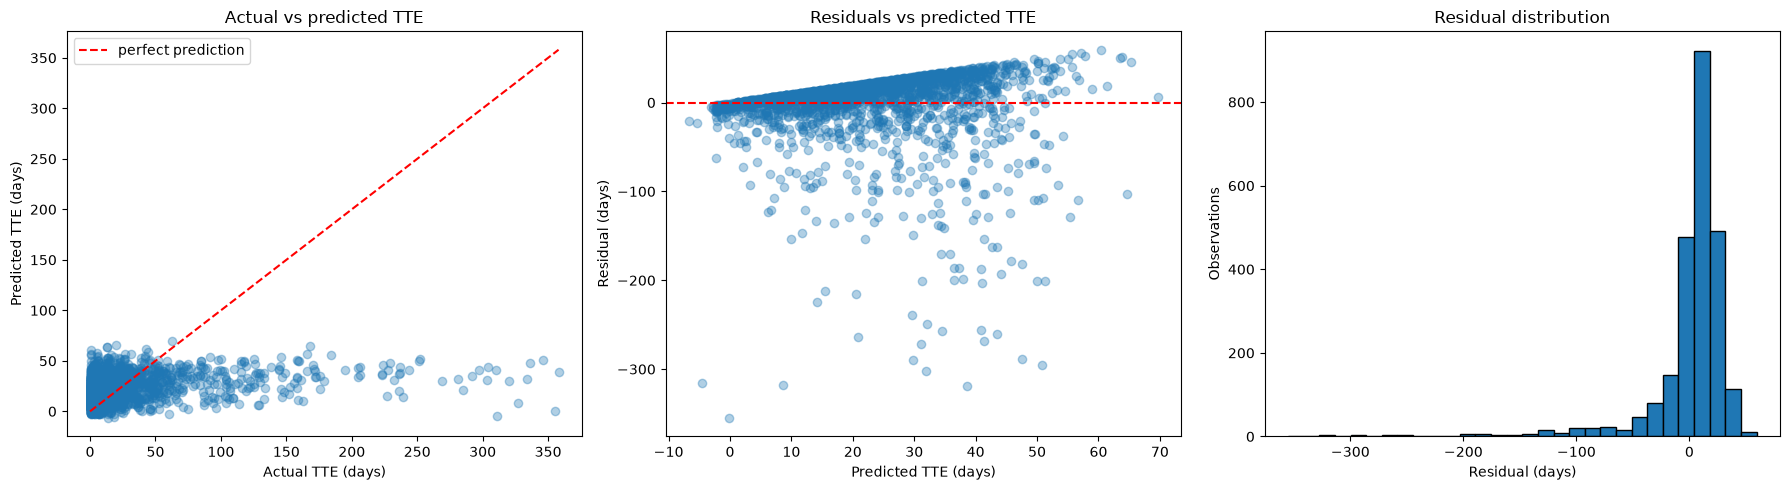

In [8]:
residuals = oof_pred - y
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y, oof_pred, alpha=0.35)
line_max = max(y.max(), oof_pred.max())
axes[0].plot([0, line_max], [0, line_max], "r--", label="perfect prediction")
axes[0].set_title("Actual vs predicted TTE")
axes[0].set_xlabel("Actual TTE (days)")
axes[0].set_ylabel("Predicted TTE (days)")
axes[0].legend()

axes[1].scatter(oof_pred, residuals, alpha=0.35)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_title("Residuals vs predicted TTE")
axes[1].set_xlabel("Predicted TTE (days)")
axes[1].set_ylabel("Residual (days)")

axes[2].hist(residuals, bins=30, edgecolor="black")
axes[2].set_title("Residual distribution")
axes[2].set_xlabel("Residual (days)")
axes[2].set_ylabel("Observations")

plt.tight_layout()
plt.show()